In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import plotly.express as px
import plotly.graph_objects as go

quiz_df = pd.read_csv('quiz_df.csv')
test_df = pd.read_csv('test_df.csv')

quiz_df.head()

,question_id,quiz_id,question_text,subtopic,student_id,module_id,module_name,attempt_number,quiz_score_percent,quiz_timestamp,quiz_duration_secs,is_correct
0,QN1,QZ01,How does exploratory data analysis enhance dec...,Intro to Data Analytics,S01,DAVA,Data Visualization & Analytics,1,40,2024-01-13 10:00:48,521,1
1,QN1,QZ01,How does exploratory data analysis enhance dec...,Intro to Data Analytics,S01,DAVA,Data Visualization & Analytics,2,30,2024-02-22 19:51:22,1549,0
2,QN1,QZ01,How does exploratory data analysis enhance dec...,Intro to Data Analytics,S01,DAVA,Data Visualization & Analytics,3,60,2024-01-16 03:24:40,1736,1
3,QN10,QZ01,How can anomaly detection in datasets improve ...,Intro to Data Analytics,S01,DAVA,Data Visualization & Analytics,1,40,2024-01-13 10:00:48,521,1
4,QN10,QZ01,How can anomaly detection in datasets improve ...,Intro to Data Analytics,S01,DAVA,Data Visualization & Analytics,2,30,2024-02-22 19:51:22,1549,1


In [2]:
test_df.head()

,question_id,test_id,subtopic,question_text,student_id,module_id,module_name,test_score_percent,test_timestamp,is_correct
0,QN1,TS01,Intro to Data Analytics,How can anomaly detection in data analytics tr...,S01,DAVA,Data Visualization & Analytics,76,2024-10-17 20:31:13,1
1,QN1,TS01,Intro to Data Analytics,How can anomaly detection in data analytics tr...,S02,DAVA,Data Visualization & Analytics,64,2024-01-11 19:10:02,1
2,QN1,TS01,Intro to Data Analytics,How can anomaly detection in data analytics tr...,S03,DAVA,Data Visualization & Analytics,76,2024-02-26 19:09:42,1
3,QN1,TS01,Intro to Data Analytics,How can anomaly detection in data analytics tr...,S04,DAVA,Data Visualization & Analytics,92,2024-11-28 11:33:06,1
4,QN1,TS01,Intro to Data Analytics,How can anomaly detection in data analytics tr...,S05,DAVA,Data Visualization & Analytics,64,2024-01-01 20:51:22,1


## Quiz_df aggregated by subtopic + aggregated by module

In [3]:
## DO NOT SUM UP IS_CORRECT. you're summing different attempts of the same student. 
# if u get 40% in your first attempt`` and 70% in your second attempt, 
# the quiz_score_percent is 70% and is_correct is 7
quiz_df_agg_subtopic = quiz_df.groupby(['student_id', 'module_id', 'subtopic']).agg({
                                                    'quiz_id':'unique', # js to check one-to-one-match between subtopic and quiz_id
                                                    'quiz_score_percent':'max'}).reset_index()

# first(1st occurrence), last, max, min, mean, sum, count, nunique
quiz_df_agg_subtopic.sort_values(by=['student_id', 'module_id', 'subtopic'], ascending=True)

# check there is a **one-to-one match between subtopic and quiz_id** 
assert all(quiz_df_agg_subtopic['quiz_id'].apply(lambda x: len(x) == 1))

quiz_df_agg_subtopic.head(20)

,student_id,module_id,subtopic,quiz_id,quiz_score_percent
0,S01,DAVA,Data Preparation,[QZ03],90
1,S01,DAVA,Exploratory Data Analysis,[QZ02],100
2,S01,DAVA,Intro to Data Analytics,[QZ01],60
3,S01,DAVA,Predictive Analytics,[QZ04],60
4,S01,DSES,Cluster Analysis in Python (K-Means Clustering),[QZ16],70
5,S01,DSES,Data Manipulation in pandas,[QZ12],90
6,S01,DSES,Dealing with Missing Data in Python,[QZ11],70
7,S01,DSES,EDA in Python,[QZ13],70
8,S01,DSES,Introduction to Data Science in Python,[QZ10],90
9,S01,DSES,Introduction to Data Visualisation with Seaborn,[QZ14],70


In [4]:
quiz_df_agg_module = quiz_df_agg_subtopic.groupby(['student_id', 'module_id']).agg({'quiz_score_percent':'mean'}).reset_index()
quiz_df_agg_module['quiz_score_percent'] = quiz_df_agg_module['quiz_score_percent'].round(1)
quiz_df_agg_module

,student_id,module_id,quiz_score_percent
0,S01,DAVA,77.5
1,S01,DSES,75.7
2,S01,DWBI,70.0
3,S01,LOMA,76.0
4,S02,DAVA,62.5
...,...,...,...
195,S49,LOMA,84.0
196,S50,DAVA,75.0
197,S50,DSES,55.7
198,S50,DWBI,65.0


## Test_df aggregated by subtopic + aggregated by module

In [5]:
test_df

,question_id,test_id,subtopic,question_text,student_id,module_id,module_name,test_score_percent,test_timestamp,is_correct
0,QN1,TS01,Intro to Data Analytics,How can anomaly detection in data analytics tr...,S01,DAVA,Data Visualization & Analytics,76,2024-10-17 20:31:13,1
1,QN1,TS01,Intro to Data Analytics,How can anomaly detection in data analytics tr...,S02,DAVA,Data Visualization & Analytics,64,2024-01-11 19:10:02,1
2,QN1,TS01,Intro to Data Analytics,How can anomaly detection in data analytics tr...,S03,DAVA,Data Visualization & Analytics,76,2024-02-26 19:09:42,1
3,QN1,TS01,Intro to Data Analytics,How can anomaly detection in data analytics tr...,S04,DAVA,Data Visualization & Analytics,92,2024-11-28 11:33:06,1
4,QN1,TS01,Intro to Data Analytics,How can anomaly detection in data analytics tr...,S05,DAVA,Data Visualization & Analytics,64,2024-01-01 20:51:22,1
...,...,...,...,...,...,...,...,...,...,...
9995,QN150,TS08,DW Model: DW Schemas,How does a snowflake schema optimize data stor...,S46,DWBI,Data Warehousing & Business Intelligence,84,2024-03-26 04:06:58,1
9996,QN150,TS08,DW Model: DW Schemas,How does a snowflake schema optimize data stor...,S47,DWBI,Data Warehousing & Business Intelligence,92,2024-11-09 01:02:57,1
9997,QN150,TS08,DW Model: DW Schemas,How does a snowflake schema optimize data stor...,S48,DWBI,Data Warehousing & Business Intelligence,56,2024-10-22 20:34:17,0
9998,QN150,TS08,DW Model: DW Schemas,How does a snowflake schema optimize data stor...,S49,DWBI,Data Warehousing & Business Intelligence,72,2024-07-16 05:24:44,0


In [6]:
pd.set_option('display.max_colwidth', None)
test_df.groupby(['module_id', 'subtopic']).agg({'question_id': 'nunique'}).reset_index()

,module_id,subtopic,question_id
0,DAVA,Data Preparation,12
1,DAVA,Exploratory Data Analysis,12
2,DAVA,Intro to Data Analytics,14
3,DAVA,Predictive Analytics,12
4,DSES,Cluster Analysis in Python (K-Means Clustering),6
5,DSES,Data Manipulation in pandas,8
6,DSES,Dealing with Missing Data in Python,8
7,DSES,EDA in Python,8
8,DSES,Introduction to Data Science in Python,8
9,DSES,Introduction to Data Visualisation with Seaborn,6


In [7]:
test_df_agg_subtopic = test_df.groupby(['student_id', 'module_id', 'subtopic']).agg({
                                                    'is_correct':'sum', 'question_id': 'nunique'}).reset_index()

test_df_agg_subtopic.rename(columns={'is_correct':'is_correct_by_subtopic', 'question_id': 'question_count_by_subtopic'}, inplace=True)
# first(1st occurrence), last, max, min, mean, sum, count, nunique

test_df_agg_subtopic.sort_values(by=['student_id', 'module_id', 'subtopic'], ascending=True)

assert all(test_df_agg_subtopic['question_count_by_subtopic'] >= test_df_agg_subtopic['is_correct_by_subtopic'])

test_df_agg_subtopic

,student_id,module_id,subtopic,is_correct_by_subtopic,question_count_by_subtopic
0,S01,DAVA,Data Preparation,11,12
1,S01,DAVA,Exploratory Data Analysis,10,12
2,S01,DAVA,Intro to Data Analytics,13,14
3,S01,DAVA,Predictive Analytics,10,12
4,S01,DSES,Cluster Analysis in Python (K-Means Clustering),6,6
...,...,...,...,...,...
995,S50,LOMA,Function,8,10
996,S50,LOMA,Graphs,9,10
997,S50,LOMA,Logic,10,10
998,S50,LOMA,Probability,8,10


In [8]:
# calculate the percentage of questions answered correctly for each subtopic
# this splits the tests up into subtopics, much like the quizzes 

test_df_agg_subtopic['test_percentage_correct'] = (test_df_agg_subtopic['is_correct_by_subtopic'] / test_df_agg_subtopic['question_count_by_subtopic'] * 100).astype(int)
test_df_agg_subtopic.drop(columns=['is_correct_by_subtopic', 'question_count_by_subtopic'], errors='ignore', inplace=True)

test_df_agg_subtopic

,student_id,module_id,subtopic,test_percentage_correct
0,S01,DAVA,Data Preparation,91
1,S01,DAVA,Exploratory Data Analysis,83
2,S01,DAVA,Intro to Data Analytics,92
3,S01,DAVA,Predictive Analytics,83
4,S01,DSES,Cluster Analysis in Python (K-Means Clustering),100
...,...,...,...,...
995,S50,LOMA,Function,80
996,S50,LOMA,Graphs,90
997,S50,LOMA,Logic,100
998,S50,LOMA,Probability,80


In [9]:
test_df_agg_module = test_df.groupby(['student_id','module_id']).agg({'is_correct':'sum', 'question_id':'count'}).reset_index()
test_df_agg_module['test_percentage_correct'] = (test_df_agg_module['is_correct'] / test_df_agg_module['question_id'] * 100).astype(int)
test_df_agg_module.drop(columns=['is_correct', 'question_id'], inplace=True)
test_df_agg_module


,student_id,module_id,test_percentage_correct
0,S01,DAVA,88
1,S01,DSES,86
2,S01,DWBI,62
3,S01,LOMA,64
4,S02,DAVA,60
...,...,...,...
195,S49,LOMA,62
196,S50,DAVA,64
197,S50,DSES,70
198,S50,DWBI,82


In [10]:
combined_results_subtopic = pd.merge(quiz_df_agg_subtopic.drop(columns='quiz_id'), test_df_agg_subtopic, on=['student_id', 'module_id', 'subtopic'])
combined_results_subtopic

,student_id,module_id,subtopic,quiz_score_percent,test_percentage_correct
0,S01,DAVA,Data Preparation,90,91
1,S01,DAVA,Exploratory Data Analysis,100,83
2,S01,DAVA,Intro to Data Analytics,60,92
3,S01,DAVA,Predictive Analytics,60,83
4,S01,DSES,Cluster Analysis in Python (K-Means Clustering),70,100
...,...,...,...,...,...
995,S50,LOMA,Function,30,80
996,S50,LOMA,Graphs,40,90
997,S50,LOMA,Logic,80,100
998,S50,LOMA,Probability,60,80


## Step 1: Clustering by overall module-level grades

In [11]:
combined_results_module = pd.merge(quiz_df_agg_module, test_df_agg_module, on=['student_id', 'module_id'])
combined_results_module.head(50)

,student_id,module_id,quiz_score_percent,test_percentage_correct
0,S01,DAVA,77.5,88
1,S01,DSES,75.7,86
2,S01,DWBI,70.0,62
3,S01,LOMA,76.0,64
4,S02,DAVA,62.5,60
5,S02,DSES,70.0,60
6,S02,DWBI,80.0,74
7,S02,LOMA,68.0,86
8,S03,DAVA,77.5,70
9,S03,DSES,75.7,57


In [12]:


long_df = combined_results_module.melt(
    id_vars=['student_id', 'module_id'],
    value_vars=['quiz_score_percent', 'test_percentage_correct'],
    var_name='metric',
    value_name='score'
)

# Step 2: Create a new column that combines module_id and metric
long_df['module_metric'] = long_df['module_id'] + '_' + long_df['metric'].str.replace('quiz_score_percent', 'quiz').str.replace('test_percentage_correct', 'test')

# Step 3: Pivot the DataFrame so each student is a row and module-metric is a column
reshaped_df = long_df.pivot(index='student_id', columns='module_metric', values='score').reset_index()
reshaped_df.columns.name = None
reshaped_df.head(50)

,student_id,DAVA_quiz,DAVA_test,DSES_quiz,DSES_test,DWBI_quiz,DWBI_test,LOMA_quiz,LOMA_test
0,S01,77.5,88.0,75.7,86.0,70.0,62.0,76.0,64.0
1,S02,62.5,60.0,70.0,60.0,80.0,74.0,68.0,86.0
2,S03,77.5,70.0,75.7,57.0,72.5,56.0,74.0,57.0
3,S04,80.0,92.0,72.9,90.0,62.5,62.0,76.0,66.0
4,S05,82.5,70.0,70.0,66.0,45.0,88.0,62.0,74.0
5,S06,85.0,62.0,67.1,46.0,77.5,62.0,66.0,50.0
6,S07,65.0,86.0,67.1,82.0,52.5,72.0,66.0,57.0
7,S08,57.5,62.0,78.6,66.0,65.0,78.0,62.0,92.0
8,S09,47.5,57.0,70.0,54.0,75.0,60.0,72.0,64.0
9,S10,72.5,80.0,70.0,84.0,85.0,70.0,70.0,72.0


In [13]:
reshaped_df.drop(columns='student_id', inplace=True, errors='ignore')
reshaped_df.describe() # k-means can only accept continuous numeric data

,DAVA_quiz,DAVA_test,DSES_quiz,DSES_test,DWBI_quiz,DWBI_test,LOMA_quiz,LOMA_test
count,50.000000,50.000000,50.000000,50.000000,50.00000,50.000000,50.000000,50.000000
mean,71.350000,70.180000,70.060000,68.500000,67.85000,68.800000,68.080000,69.660000
std,10.427226,13.470588,6.575837,13.601095,11.30525,13.653137,10.659555,11.826311
min,47.500000,48.000000,52.900000,46.000000,42.50000,44.000000,38.000000,50.000000
25%,65.000000,60.000000,67.100000,57.000000,60.62500,57.000000,62.000000,62.000000
50%,72.500000,64.000000,70.000000,66.000000,67.50000,66.000000,68.000000,65.000000
75%,77.500000,83.500000,73.950000,82.000000,75.00000,81.500000,76.000000,81.000000
max,97.500000,98.000000,84.300000,94.000000,90.00000,94.000000,90.000000,92.000000


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
reshaped_df_scaled = scaler.fit_transform(reshaped_df)

reshaped_df_scaled = pd.DataFrame(reshaped_df_scaled, columns=reshaped_df.columns)

reshaped_df_scaled.head(50)

,DAVA_quiz,DAVA_test,DSES_quiz,DSES_test,DWBI_quiz,DWBI_test,LOMA_quiz,LOMA_test
0,0.595790,1.336313,0.866393,1.299724,0.192108,-0.503111,0.750539,-0.483453
1,-0.857357,-0.763393,-0.009217,-0.631294,1.085633,0.384732,-0.007581,1.395692
2,0.595790,-0.013498,0.866393,-0.854104,0.415489,-0.947032,0.561009,-1.081363
3,0.837981,1.636271,0.436269,1.596804,-0.478036,-0.503111,0.750539,-0.312621
4,1.080172,-0.013498,-0.009217,-0.185675,-2.041705,1.420547,-0.576171,0.370704
5,1.322363,-0.613414,-0.454703,-1.671074,0.862252,-0.503111,-0.197111,-1.679273
6,-0.615165,1.186334,-0.454703,1.002644,-1.371561,0.236758,-0.197111,-1.081363
7,-1.341739,-0.613414,1.311879,-0.185675,-0.254655,0.680679,-0.576171,1.908187
8,-2.310503,-0.988362,-0.009217,-1.076914,0.638871,-0.651084,0.371479,-0.483453
9,0.111408,0.736397,-0.009217,1.151184,1.532396,0.088784,0.181949,0.199873


In [16]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

results = []

kmin, kmax = 2, 10


for k in range(kmin, kmax + 1):
    kmeans_k = KMeans(n_clusters=k, init="k-means++", random_state=42)
    labels = kmeans_k.fit_predict(reshaped_df_scaled)
    score = silhouette_score(reshaped_df_scaled, labels)
    results.append({"k": k, "silhouette_score": score})

df_scores = pd.DataFrame(results)
print(df_scores)
print(df_scores.loc[df_scores['silhouette_score'].idxmax()])

    k  silhouette_score
0   2          0.184109
1   3          0.273449
2   4          0.316441
3   5          0.247337
4   6          0.184740
5   7          0.166304
6   8          0.172762
7   9          0.169288
8  10          0.118933
k                   4.000000
silhouette_score    0.316441
Name: 2, dtype: float64


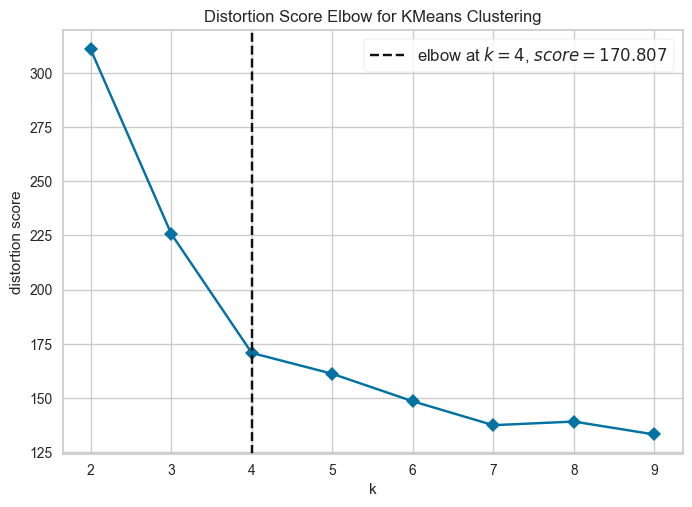

Optimal k according to the elbow: 4
   DAVA_quiz  DAVA_test  DSES_quiz  DSES_test  DWBI_quiz  DWBI_test  \
0   0.595790   1.336313   0.866393   1.299724   0.192108  -0.503111   
1  -0.857357  -0.763393  -0.009217  -0.631294   1.085633   0.384732   
2   0.595790  -0.013498   0.866393  -0.854104   0.415489  -0.947032   
3   0.837981   1.636271   0.436269   1.596804  -0.478036  -0.503111   
4   1.080172  -0.013498  -0.009217  -0.185675  -2.041705   1.420547   

   LOMA_quiz  LOMA_test  cluster  
0   0.750539  -0.483453        0  
1  -0.007581   1.395692        3  
2   0.561009  -1.081363        2  
3   0.750539  -0.312621        0  
4  -0.576171   0.370704        3  


In [17]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt

# --- 2. Choose a sensible range for k ------------------------------------
# Feel free to widen or narrow this range
kmin, kmax = 2, 10

# Instantiate the model (no n_clusters yet!)
kmeans = KMeans(init="k-means++", random_state=42)

# Yellowbrick does the elbow plot & picks the "best" k for you
visualizer = KElbowVisualizer(
    kmeans, k=(kmin, kmax), metric="distortion", timings=False
)

visualizer.fit(reshaped_df_scaled)      # <-- your scaled data
visualizer.poof()                       # renders the elbow chart

# Retrieve the elbow’s suggestion
optimal_k = visualizer.elbow_value_
print(f"Optimal k according to the elbow: {optimal_k}")

# --- 3. Fit final K-means with the chosen k ------------------------------
final_kmeans = KMeans(
    n_clusters=optimal_k,
    init="k-means++",
    n_init="auto",
    random_state=42
).fit(reshaped_df_scaled)

# --- 4. Attach cluster labels back to the DataFrame ----------------------
reshaped_df_clustered = reshaped_df_scaled.copy()
reshaped_df_clustered["cluster"] = final_kmeans.labels_

# (Optional) quick peek
print(reshaped_df_clustered.head())

In [18]:
reshaped_df_scaled

,DAVA_quiz,DAVA_test,DSES_quiz,DSES_test,DWBI_quiz,DWBI_test,LOMA_quiz,LOMA_test
0,0.595790,1.336313,0.866393,1.299724,0.192108,-0.503111,0.750539,-0.483453
1,-0.857357,-0.763393,-0.009217,-0.631294,1.085633,0.384732,-0.007581,1.395692
2,0.595790,-0.013498,0.866393,-0.854104,0.415489,-0.947032,0.561009,-1.081363
3,0.837981,1.636271,0.436269,1.596804,-0.478036,-0.503111,0.750539,-0.312621
4,1.080172,-0.013498,-0.009217,-0.185675,-2.041705,1.420547,-0.576171,0.370704
5,1.322363,-0.613414,-0.454703,-1.671074,0.862252,-0.503111,-0.197111,-1.679273
6,-0.615165,1.186334,-0.454703,1.002644,-1.371561,0.236758,-0.197111,-1.081363
7,-1.341739,-0.613414,1.311879,-0.185675,-0.254655,0.680679,-0.576171,1.908187
8,-2.310503,-0.988362,-0.009217,-1.076914,0.638871,-0.651084,0.371479,-0.483453
9,0.111408,0.736397,-0.009217,1.151184,1.532396,0.088784,0.181949,0.199873


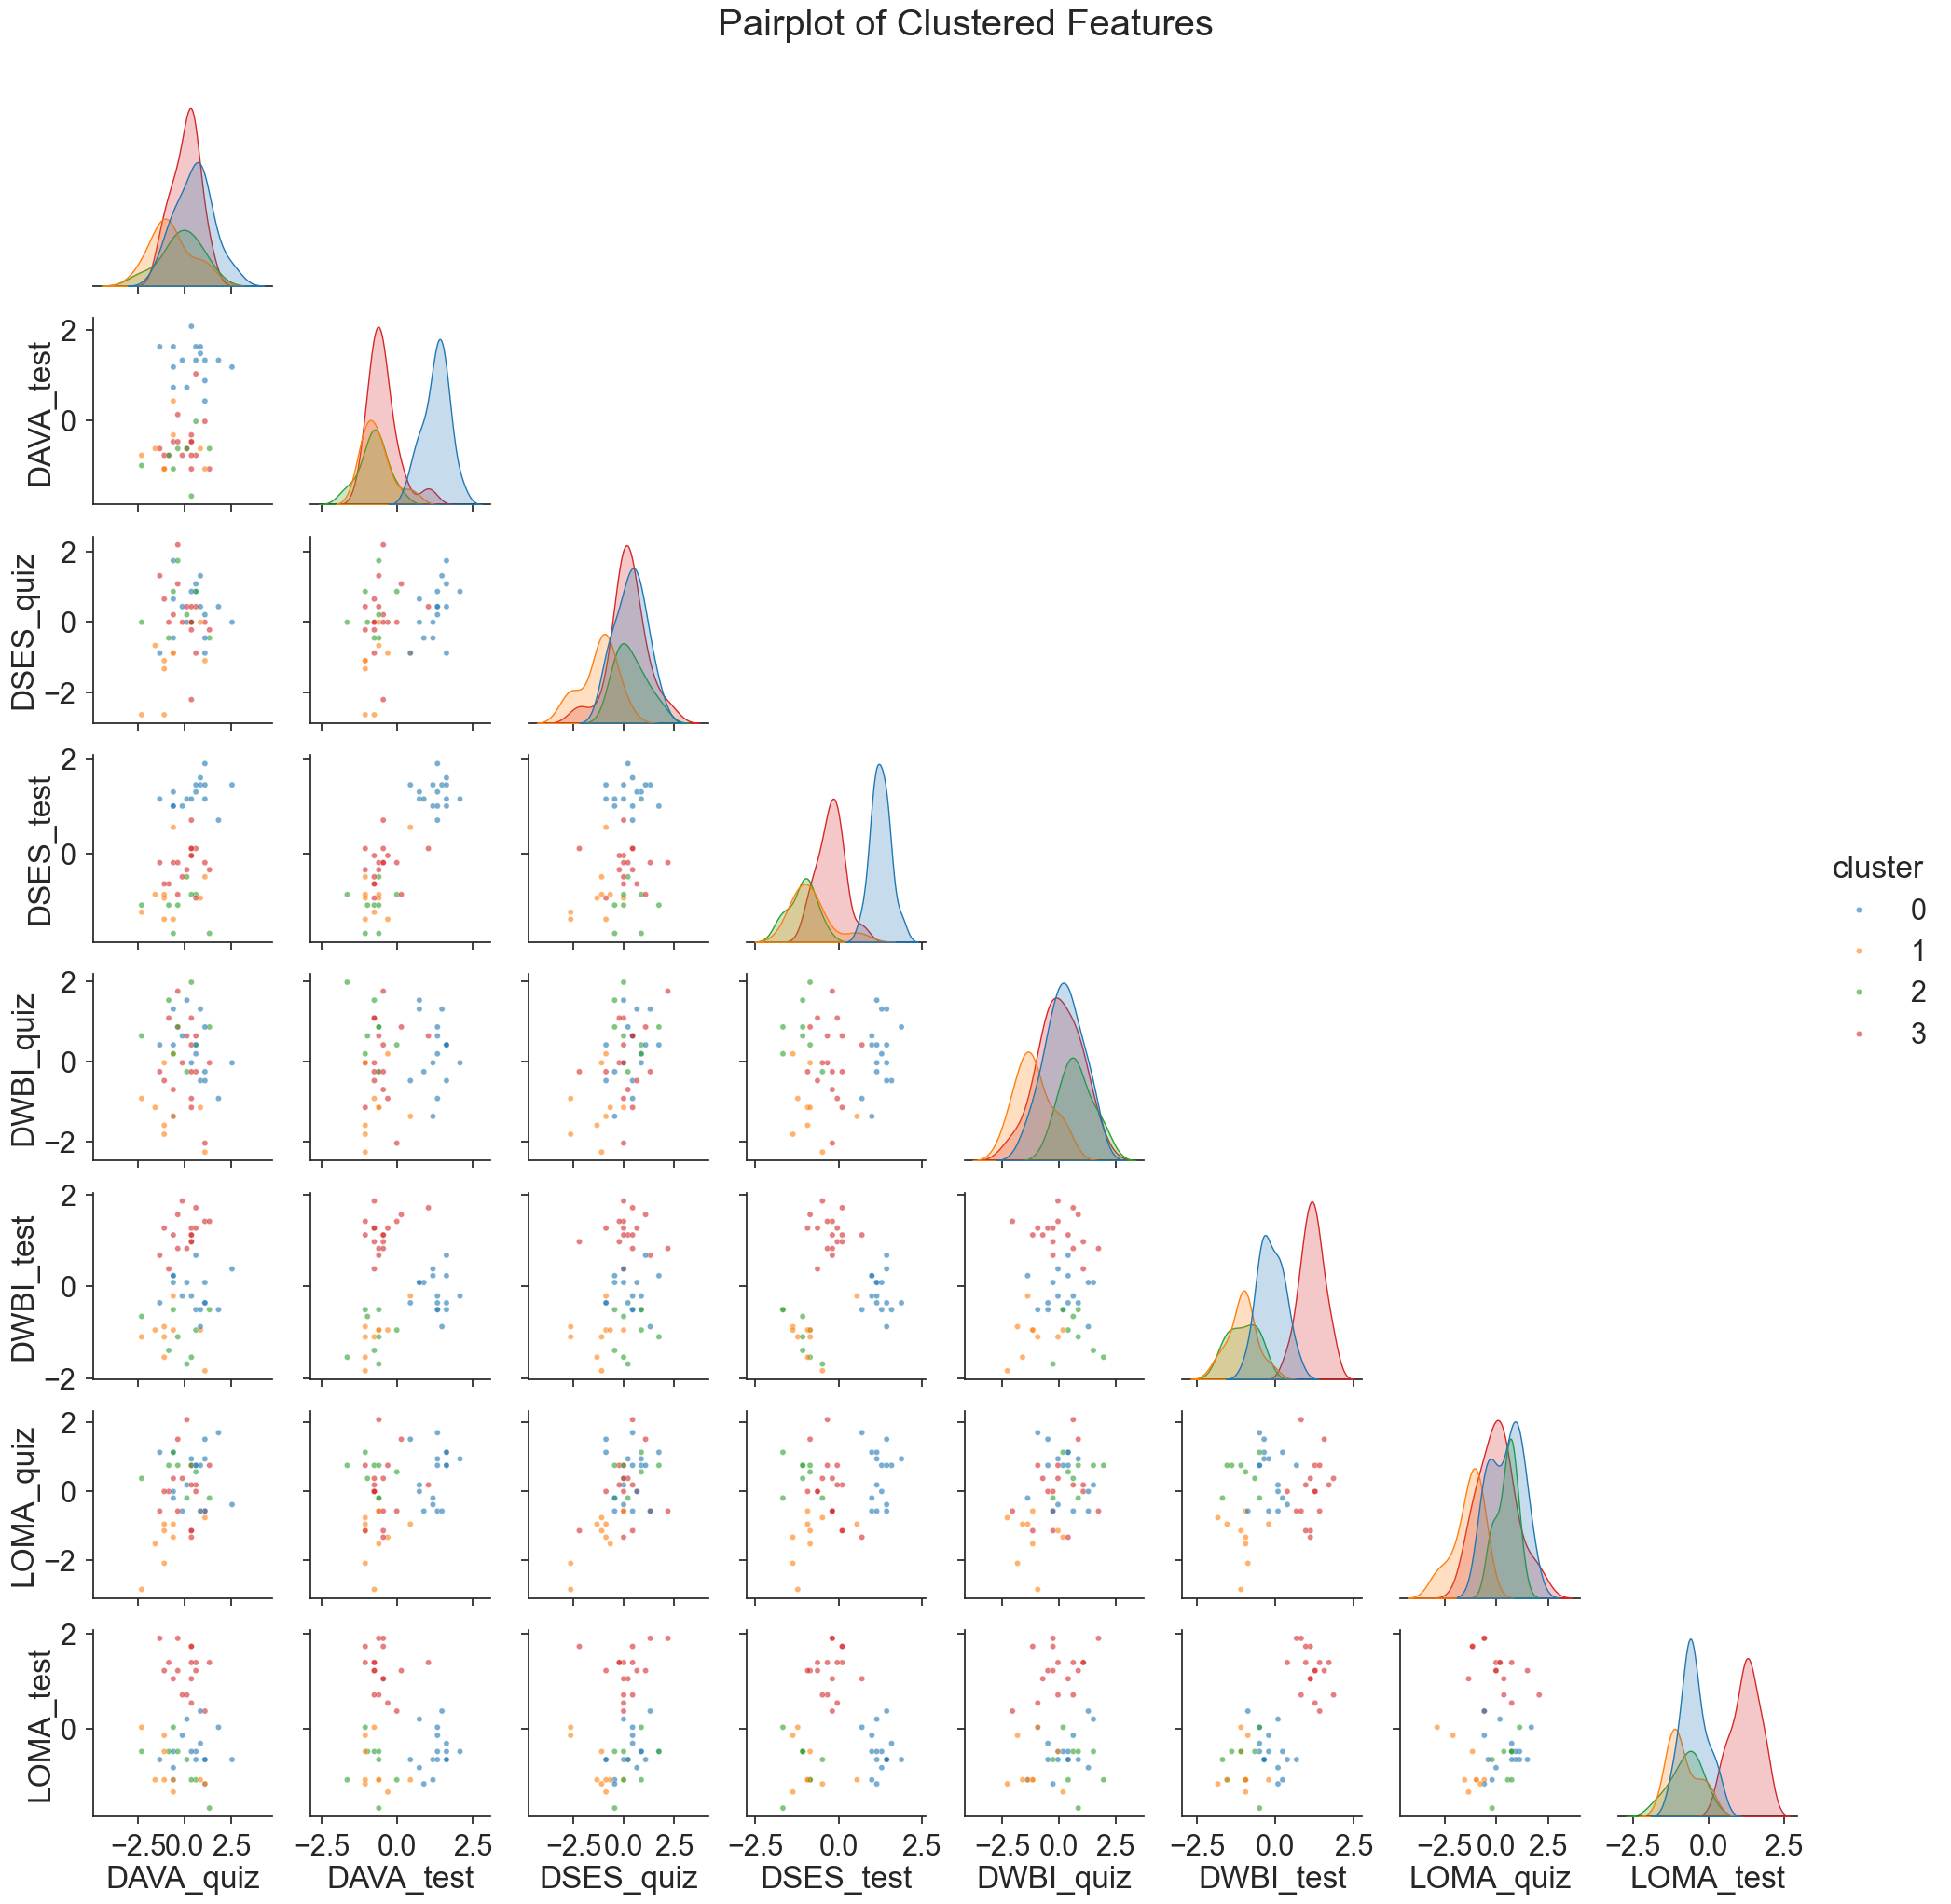

In [19]:
sns.set_theme(font_scale=2, style='ticks', color_codes=True)
pairgrid = sns.pairplot(
    reshaped_df_clustered,
    hue="cluster",          # drop this if no -> numeric_df = numeric_df.drop(columns="cluster")
    corner=True,
    diag_kind="kde",
    plot_kws=dict(alpha=0.6, s=20),   # transparency + point size
    palette='tab10'
)

pairgrid.figure.suptitle("Pairplot of Clustered Features", y=1.03)  # tidy title
plt.show()

/Users/macbook/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


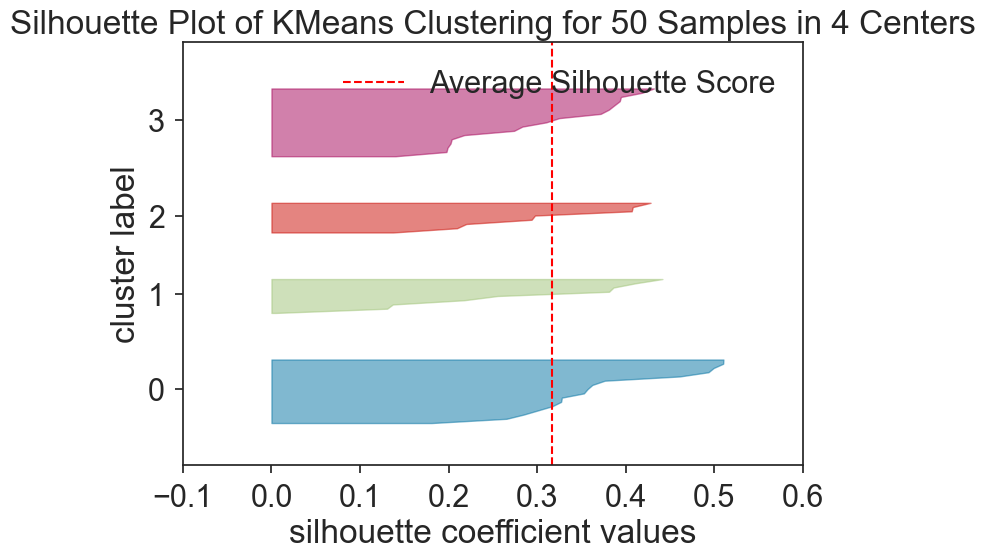

/Users/macbook/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(
/Users/macbook/miniconda3/lib/python3.11/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


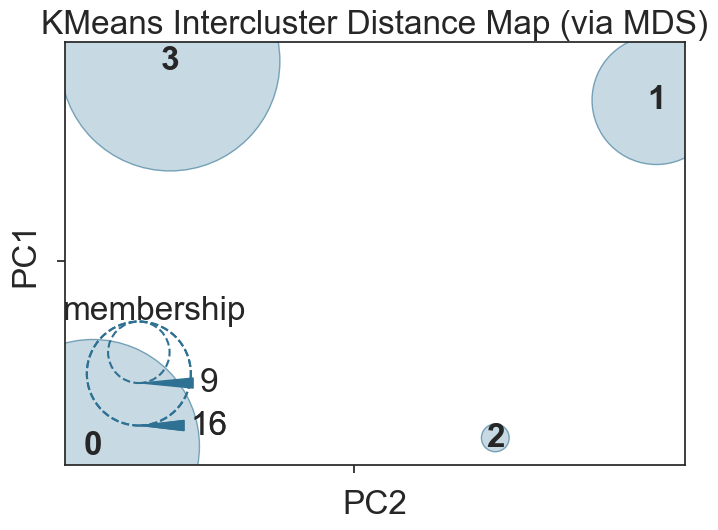

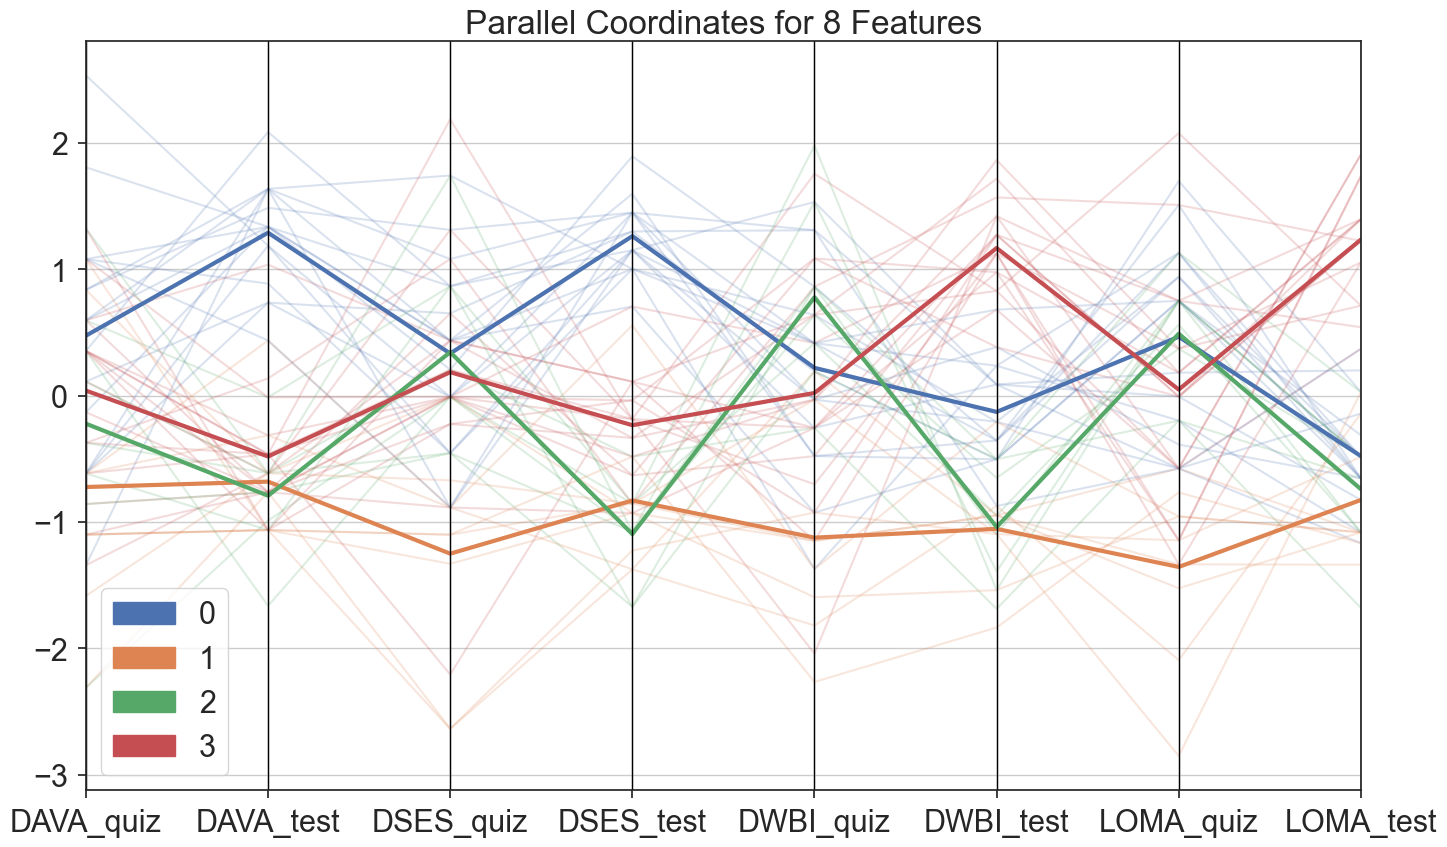

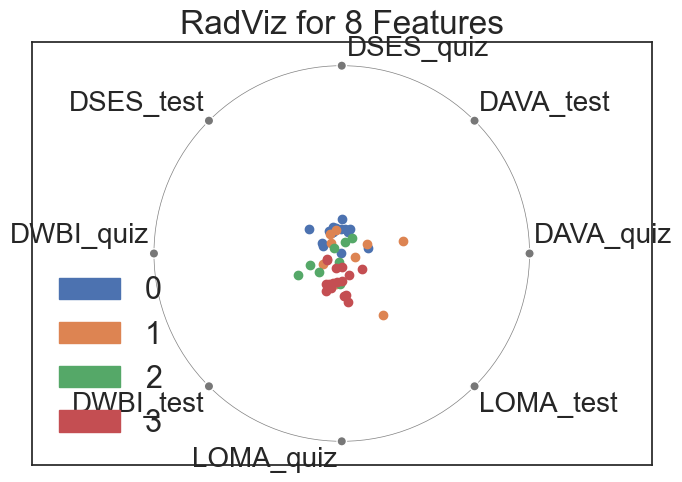

<Axes: title={'center': 'RadViz for 8 Features'}>

In [20]:
from yellowbrick.cluster import SilhouetteVisualizer, InterclusterDistance
from yellowbrick.features import ParallelCoordinates, RadViz

# 3. Silhouette plot
sil_viz = SilhouetteVisualizer(final_kmeans, colors="yellowbrick")
sil_viz.fit(reshaped_df_scaled)     # X must exactly match the data you called .fit on
sil_viz.show()

# 4. Intercluster distance map
dist_viz = InterclusterDistance(final_kmeans)
dist_viz.fit(reshaped_df_scaled)
dist_viz.show()

# 5. Parallel coordinates
plt.figure(figsize=(14, 9))
pc = ParallelCoordinates(
    classes=list(range(optimal_k)),
    features=reshaped_df_scaled.columns,    # list of the 9 feature names
    alpha=0.2,
    linewidth=0.8
)
pc.fit_transform(reshaped_df_scaled, final_kmeans.labels_)

# overlay the *exact* centroids from your modelœ
for k, center in enumerate(final_kmeans.cluster_centers_):
    pc.ax.plot(
        range(reshaped_df_scaled.shape[1]),
        center,
        lw=3.0,
        alpha=1.0,
        label=f"centroid {k}"
    )
    
pc.ax.legend(loc="upper right", title="Cluster centroids", fontsize="small")
pc.ax.set_title("Parallel Coordinates: individuals (faint) + centroids (bold)")
plt.tight_layout()
pc.show()

# 6. RadViz projection
radviz_viz = RadViz(classes=list(range(optimal_k)))
radviz_viz.fit_transform(reshaped_df_scaled, final_kmeans.labels_)
radviz_viz.show()

In [57]:
import numpy as np
import matplotlib.pyplot as plt



def plot_clusters_radar_inverse(final_kmeans, scaler, feature_names,
                                title="Cluster Centroids (Original Scale)", save=False):
    """
    final_kmeans : fitted sklearn KMeans
    scaler       : the SAME fitted scaler you used before k-means
                   (e.g., StandardScaler or MinMaxScaler)
    feature_names: list[str] in the same order used to fit the scaler/model
    """

    # ---- invert scaling (this is the key change) ----
    cents_scaled = final_kmeans.cluster_centers_
    cents = scaler.inverse_transform(cents_scaled)   # shape: (K, D)

    K, D = cents.shape
    assert D == len(feature_names), "Feature names must match centroid width"

    # Wrap labels (avoids clutter)
    def wrap_label(s):
        # split once at underscore; tweak to taste
        return s.replace("_", "\n", 1) if "_" in s else s

    labels = [wrap_label(s) for s in feature_names]

    # Font sizes (consistent + bigger)
    plt.rcParams.update({
        "axes.titlesize": 20,
        "xtick.labelsize": 13,
        "ytick.labelsize": 12,
        "legend.fontsize": 13
    })

    # Angles (close the loop)
    angles = np.linspace(0, 2*np.pi, D, endpoint=False).tolist()
    angles += angles[:1]

    # Figure
    fig = plt.figure(figsize=(8, 8))
    ax = plt.subplot(111, polar=True)
    ax.set_theta_offset(np.pi/2)
    ax.set_theta_direction(-1)

    # Global radial limits (nice margin)
    rmin = float(np.min(cents))
    rmax = float(np.max(cents))
    span = max(rmax - rmin, 1e-9)
    rmin -= 0.05 * span
    rmax += 0.05 * span
    ax.set_ylim(rmin, rmax)

    # Nice radial ticks
    def nice_step(lo, hi, n=6):
        raw = (hi - lo) / max(n, 1)
        mag = 10 ** np.floor(np.log10(raw)) if raw > 0 else 1
        norm = raw / mag
        if   norm < 1.5: base = 1
        elif norm < 3  : base = 2
        elif norm < 7  : base = 5
        else           : base = 10
        return base * mag

    step = nice_step(rmin, rmax, n=5)
    ticks = np.arange(np.ceil(rmin/step)*step, rmax + step*0.5, step)
    ax.set_yticks(ticks)
    ax.set_yticklabels([f"{t:.0f}" for t in ticks])
    ax.set_rlabel_position(90)

    # Axis labels around the circle
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)

    # Plot each cluster
    for k in range(K):
        vals = cents[k].tolist() + cents[k, :1].tolist()
        ax.plot(angles, vals, linewidth=2, label=f"Cluster {k}")
        ax.fill(angles, vals, alpha=0.12)

    ax.grid(True, linewidth=0.85, alpha=1)
    ax.legend(loc="upper left", bbox_to_anchor=(1.08, 1.04), frameon=False, title="Clusters")

    plt.tight_layout()
    plt.savefig("cluster_radar_inverse.png", dpi=450)
    plt.show()
    

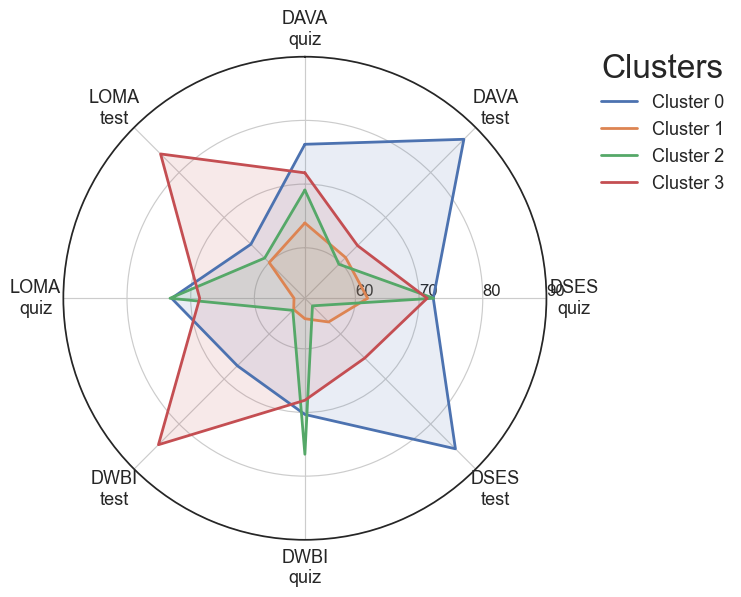

In [58]:
# Suppose you did:
# scaler = StandardScaler().fit(reshaped_df)
# X_scaled = scaler.transform(reshaped_df)
# final_kmeans.fit(X_scaled)

plot_clusters_radar_inverse(final_kmeans, scaler, list(reshaped_df.columns), save=True)